In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
os.chdir('/content/drive/MyDrive/Stock/交易策略/KD')

Mounted at /content/drive


In [2]:
! pip install backtrader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.7 MB/s eta 0:00:00


# 黃金交叉和死亡交叉的買入賣出

In [3]:
import pandas as pd
import numpy as np
import backtrader as bt
from IPython.display import display
import matplotlib.pyplot as plt

class PandasData(bt.feeds.PandasData):
    lines = ('k', 'd')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('k', 'K'),
        ('d', 'D'),
    )

class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )
    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),("lot_size", 1000),)
    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            shares = int(cash / cost_per_share)
            if shares <= 0:
              return 0

            whole_lot = (shares // self.p.lot_size) * self.p.lot_size
            if whole_lot >= self.p.lot_size:
              return whole_lot

            return shares

        return self.broker.getposition(data).size

class KDStrategy(bt.Strategy):
    params = dict(stop_loss=0.10)

    def __init__(self):
        self.k = self.data.k
        self.d = self.data.d
        self.cross = bt.ind.CrossOver(self.k, self.d)
        self.order = None
        self.buyprice = None
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            action = "買入" if order.isbuy() else "賣出"
            if order.isbuy():
                self.buyprice = exec_price

            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })
            # 關閉單筆印出以保持版面整潔，需要可取消註解
            # print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        # elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            # print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")
        elif order.status == order.Margin:
          print(f"{self.data.datetime.date(0)} Margin，重新減少股數")
          # 整股減一張
          if self.buy_size >= 2000:
              self.buy_size -= 1000

          # 一張以下改零股
          elif self.buy_size > 1:
              self.buy_size = int(self.buy_size * 0.95)

          else:
              self.buy_size = 0

          if self.buy_size > 0:
              self.order = self.buy(size=self.buy_size)
              return

        self.order = None

    def next(self):
        if self.order:
            return
        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice
            if loss <= -self.p.stop_loss:
                # print(f"{self.data.datetime.date(0)}停損觸發")
                self.order = self.close()
                return
            if self.cross < 0:
                # print(f"{self.data.datetime.date(0)}KD死亡交叉")
                self.order = self.close()
                return
        else:
            if self.cross > 0:
                # print(f"{self.data.datetime.date(0)}KD黃金交叉")
                self.order = self.buy()

    def stop(self):
        if self.position:
            # print(f"回測結束，強制結算持股：{self.position.size}股")
            self.close()


# 執行回測
def run_backtest(ticker):
    print("\n" + "="*50)
    print(f" 回測標的：{ticker}")
    print("="*50)

    # 讀取資料
    try:
        df = pd.read_csv(f"{ticker}_Cal.csv")
    except FileNotFoundError:
        print(f"找不到檔案：{ticker}_Cal.csv，跳過此標的。")
        return

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    df_bt = df[['date', 'open', 'max', 'min', 'close', 'K', 'D', 'Trading_Volume']].copy()
    df_bt = df_bt.rename(columns={"max": "high", "min": "low", "Trading_Volume": "volume"})
    df_bt = df_bt.dropna().reset_index(drop=True)
    df_bt = df_bt.set_index("date")

    # Cerebro
    cerebro = bt.Cerebro()
    cerebro.addstrategy(KDStrategy)
    cerebro.addsizer(AllInSizer, reserve=0.05)

    data = PandasData(dataname=df_bt)
    cerebro.adddata(data)
    cerebro.broker.setcash(1_000_000)

    comminfo = TaiwanStockCommission()
    cerebro.broker.addcommissioninfo(comminfo)

    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    # 執行回測
    results = cerebro.run()
    strat = results[0]

    # 整理表格
    df_trades = pd.DataFrame(strat.trades_history)
    final_val = cerebro.broker.getvalue()
    pnl_pct = (final_val / 1_000_000 - 1) * 100

    if strat.position:
        last_date = strat.data.datetime.date(0)
        pos_size = strat.position.size
        close_price = strat.data.close[0]
        unrealized_value = pos_size * close_price

        unrealized_row = pd.DataFrame([{
            "交易日期": last_date, "買賣別": "結算",
            "成交價": round(close_price, 2), "成交量(股)": pos_size,
            "交易金額": round(unrealized_value, 2), "手續費": 0.0, "證交稅": 0.0,
            "總資產": round(final_val, 2), "目前報酬率(%)": round(pnl_pct, 2)
        }])
        df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

    # 輸出 CSV
    df_trades.to_csv(f'{ticker}_df_trades.csv', index=False)

    # 績效指標計算
    mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
    sharpe_info = strat.analyzers.sharpe.get_analysis()
    sharpe = sharpe_info.get('sharperatio', None)

    trade_pnls = []
    raw_trades = df_trades[df_trades['買賣別'] != '結算'].copy()
    buy_record = None
    for _, row in df_trades.iterrows():
        if row['買賣別'] == '買入':
            buy_record = row
        elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
            cost = buy_record['交易金額'] + buy_record['手續費']
            revenue = row['交易金額'] - row['手續費'] - row['證交稅']
            pnl = revenue - cost
            trade_pnls.append(pnl)
            buy_record = None

    trade_pnls = np.array(trade_pnls)
    if len(trade_pnls) > 0:
        wins = trade_pnls[trade_pnls > 0]
        losses = trade_pnls[trade_pnls < 0]
        win_rate = (len(wins) / len(trade_pnls)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
        profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
    else:
        win_rate = profit_factor = 0.0

    print(f"最終資金：{final_val:,.2f} 元")
    print(f"總報酬率：{pnl_pct:.2f} %")
    print(f"最大回撤 (MDD)：{mdd:.2f} %")
    print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率(Sharpe)：無法計算 (無交易)")
    print(f"總交易次數：{len(trade_pnls)} 次")
    print(f"勝率：{win_rate:.2f} %")
    print(f"賺賠比：{profit_factor:.2f}")

    print("\n=== 交易紀錄表 ===")
    display(df_trades)

    # 繪圖
    plt.rcParams['figure.figsize'] = [20, 12]
    plt.rcParams['figure.dpi'] = 150
    cerebro.plot(style="candlestick", iplot=False, heightp=0.5)
    plt.show()

    return {
        "標的": ticker,
        "交易策略": "KD 黃金交叉／死亡交叉", #　交易策略有變動的話需更改
        "最終資金 (元)": round(final_val, 2),
        "總報酬率": round(pnl_pct, 2),
        "最大回撤 (MDD)": round(mdd, 2),
        "夏普比率": round(sharpe, 2) if sharpe is not None else np.nan,
        "總交易次數": len(trade_pnls),
        "勝率": round(win_rate, 2),
        "賺賠比": round(profit_factor, 2) if not np.isnan(profit_factor) else np.nan}

performance_summary = []
# 標的清單
stock_list = ["2330", "2313", "6257", "2382", "2317"]

for stock_id in stock_list:
    # run_backtest(stock_id)
    result = run_backtest(stock_id)

    if result is not None:
      performance_summary.append(result)
df_summary = pd.DataFrame(performance_summary)

# 依照報酬率排序
df_summary = df_summary.sort_values(by="總報酬率", ascending=False).reset_index(drop=True)

print("\n==============================")
print("      所有股票績效總表")
print("==============================")

display(df_summary)

df_summary.to_csv("KD_Cross_Backtest_Performance.csv", index=False, encoding="utf-8-sig")

Output hidden; open in https://colab.research.google.com to view.

# KD超買超賣


 回測標的：2330
最終資金：1,082,523.09 元
總報酬率：8.25 %
最大回撤 (MDD)：24.67 %
夏普比率(Sharpe)：0.06
總交易次數：37 次
勝率：64.86 %
賺賠比：0.60

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,319.0,3000,957000.0,1363.73,0.00,1016636.28,1.66
1,2020-02-14,賣出,337.0,3000,1011000.0,1440.67,3033.00,1048162.60,4.82
2,2020-02-26,買入,317.0,3000,951000.0,1355.17,0.00,1051307.42,5.13
3,2020-03-17,賣出,265.0,3000,795000.0,1132.88,2385.00,887289.55,-11.27
4,2020-03-18,買入,269.5,3000,808500.0,1152.11,0.00,857637.44,-14.24
...,...,...,...,...,...,...,...,...,...
69,2025-12-08,賣出,1465.0,646,946390.0,1348.61,2839.17,989672.66,-1.03
70,2025-12-19,買入,1455.0,656,954480.0,1360.13,0.00,971912.53,-2.81
71,2025-12-30,賣出,1515.0,656,993840.0,1416.22,2981.52,1023274.79,2.33
72,2026-05-22,買入,2245.0,435,976575.0,1391.62,0.00,1026233.17,2.62


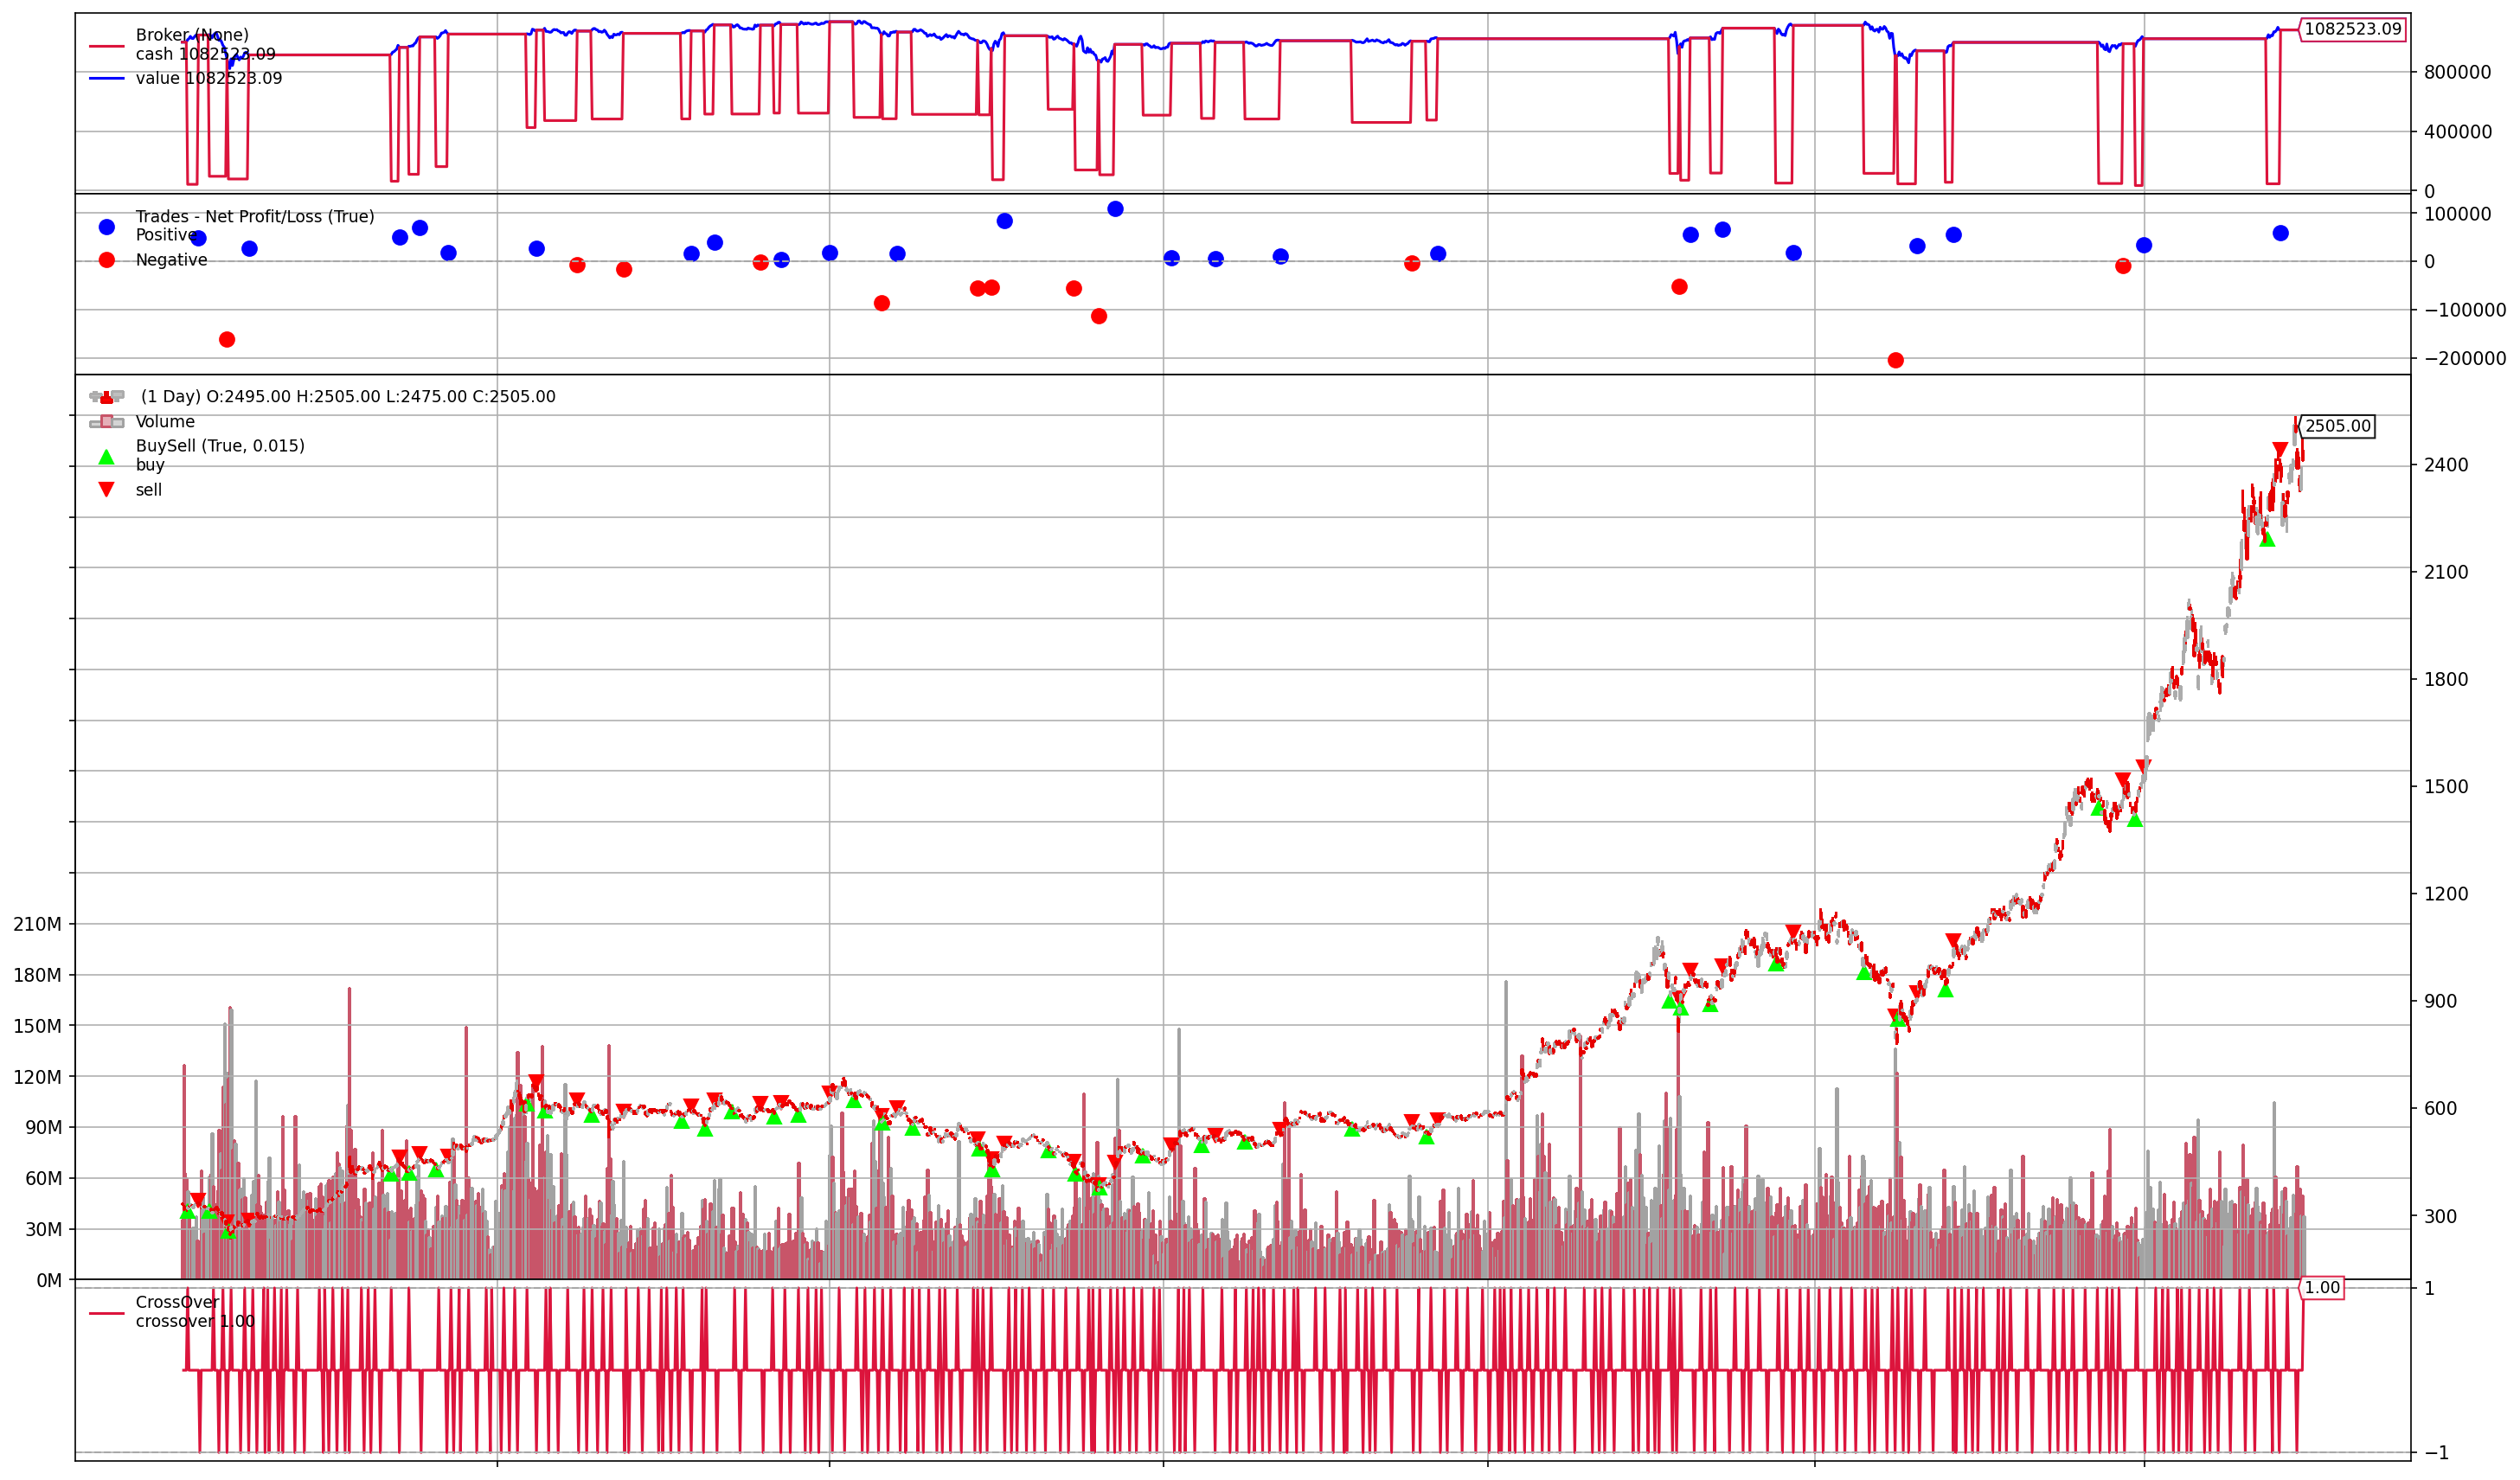


 回測標的：2313
最終資金：2,106,463.30 元
總報酬率：110.65 %
最大回撤 (MDD)：38.06 %
夏普比率(Sharpe)：0.48
總交易次數：41 次
勝率：60.98 %
賺賠比：1.02

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-03-04,買入,39.70,23000,913100.0,1301.17,0.00,991798.83,-0.82
1,2020-03-13,賣出,31.40,23000,722200.0,1029.13,2166.60,804603.10,-19.54
2,2020-03-16,買入,32.60,23000,749800.0,1068.47,0.00,736834.63,-26.32
3,2020-03-18,賣出,28.25,23000,649750.0,925.89,1949.25,700609.49,-29.94
4,2020-03-19,買入,25.50,25000,637500.0,908.44,0.00,649701.05,-35.03
...,...,...,...,...,...,...,...,...,...
77,2026-04-01,賣出,266.50,8000,2132000.0,3038.10,6396.00,2427198.55,142.72
78,2026-04-21,買入,252.50,9000,2272500.0,3238.31,0.00,2441960.23,144.20
79,2026-04-24,賣出,218.00,9000,1962000.0,2795.85,5886.00,2104778.38,110.48
80,2026-04-27,買入,219.50,9000,1975500.0,2815.09,0.00,2245963.30,124.60


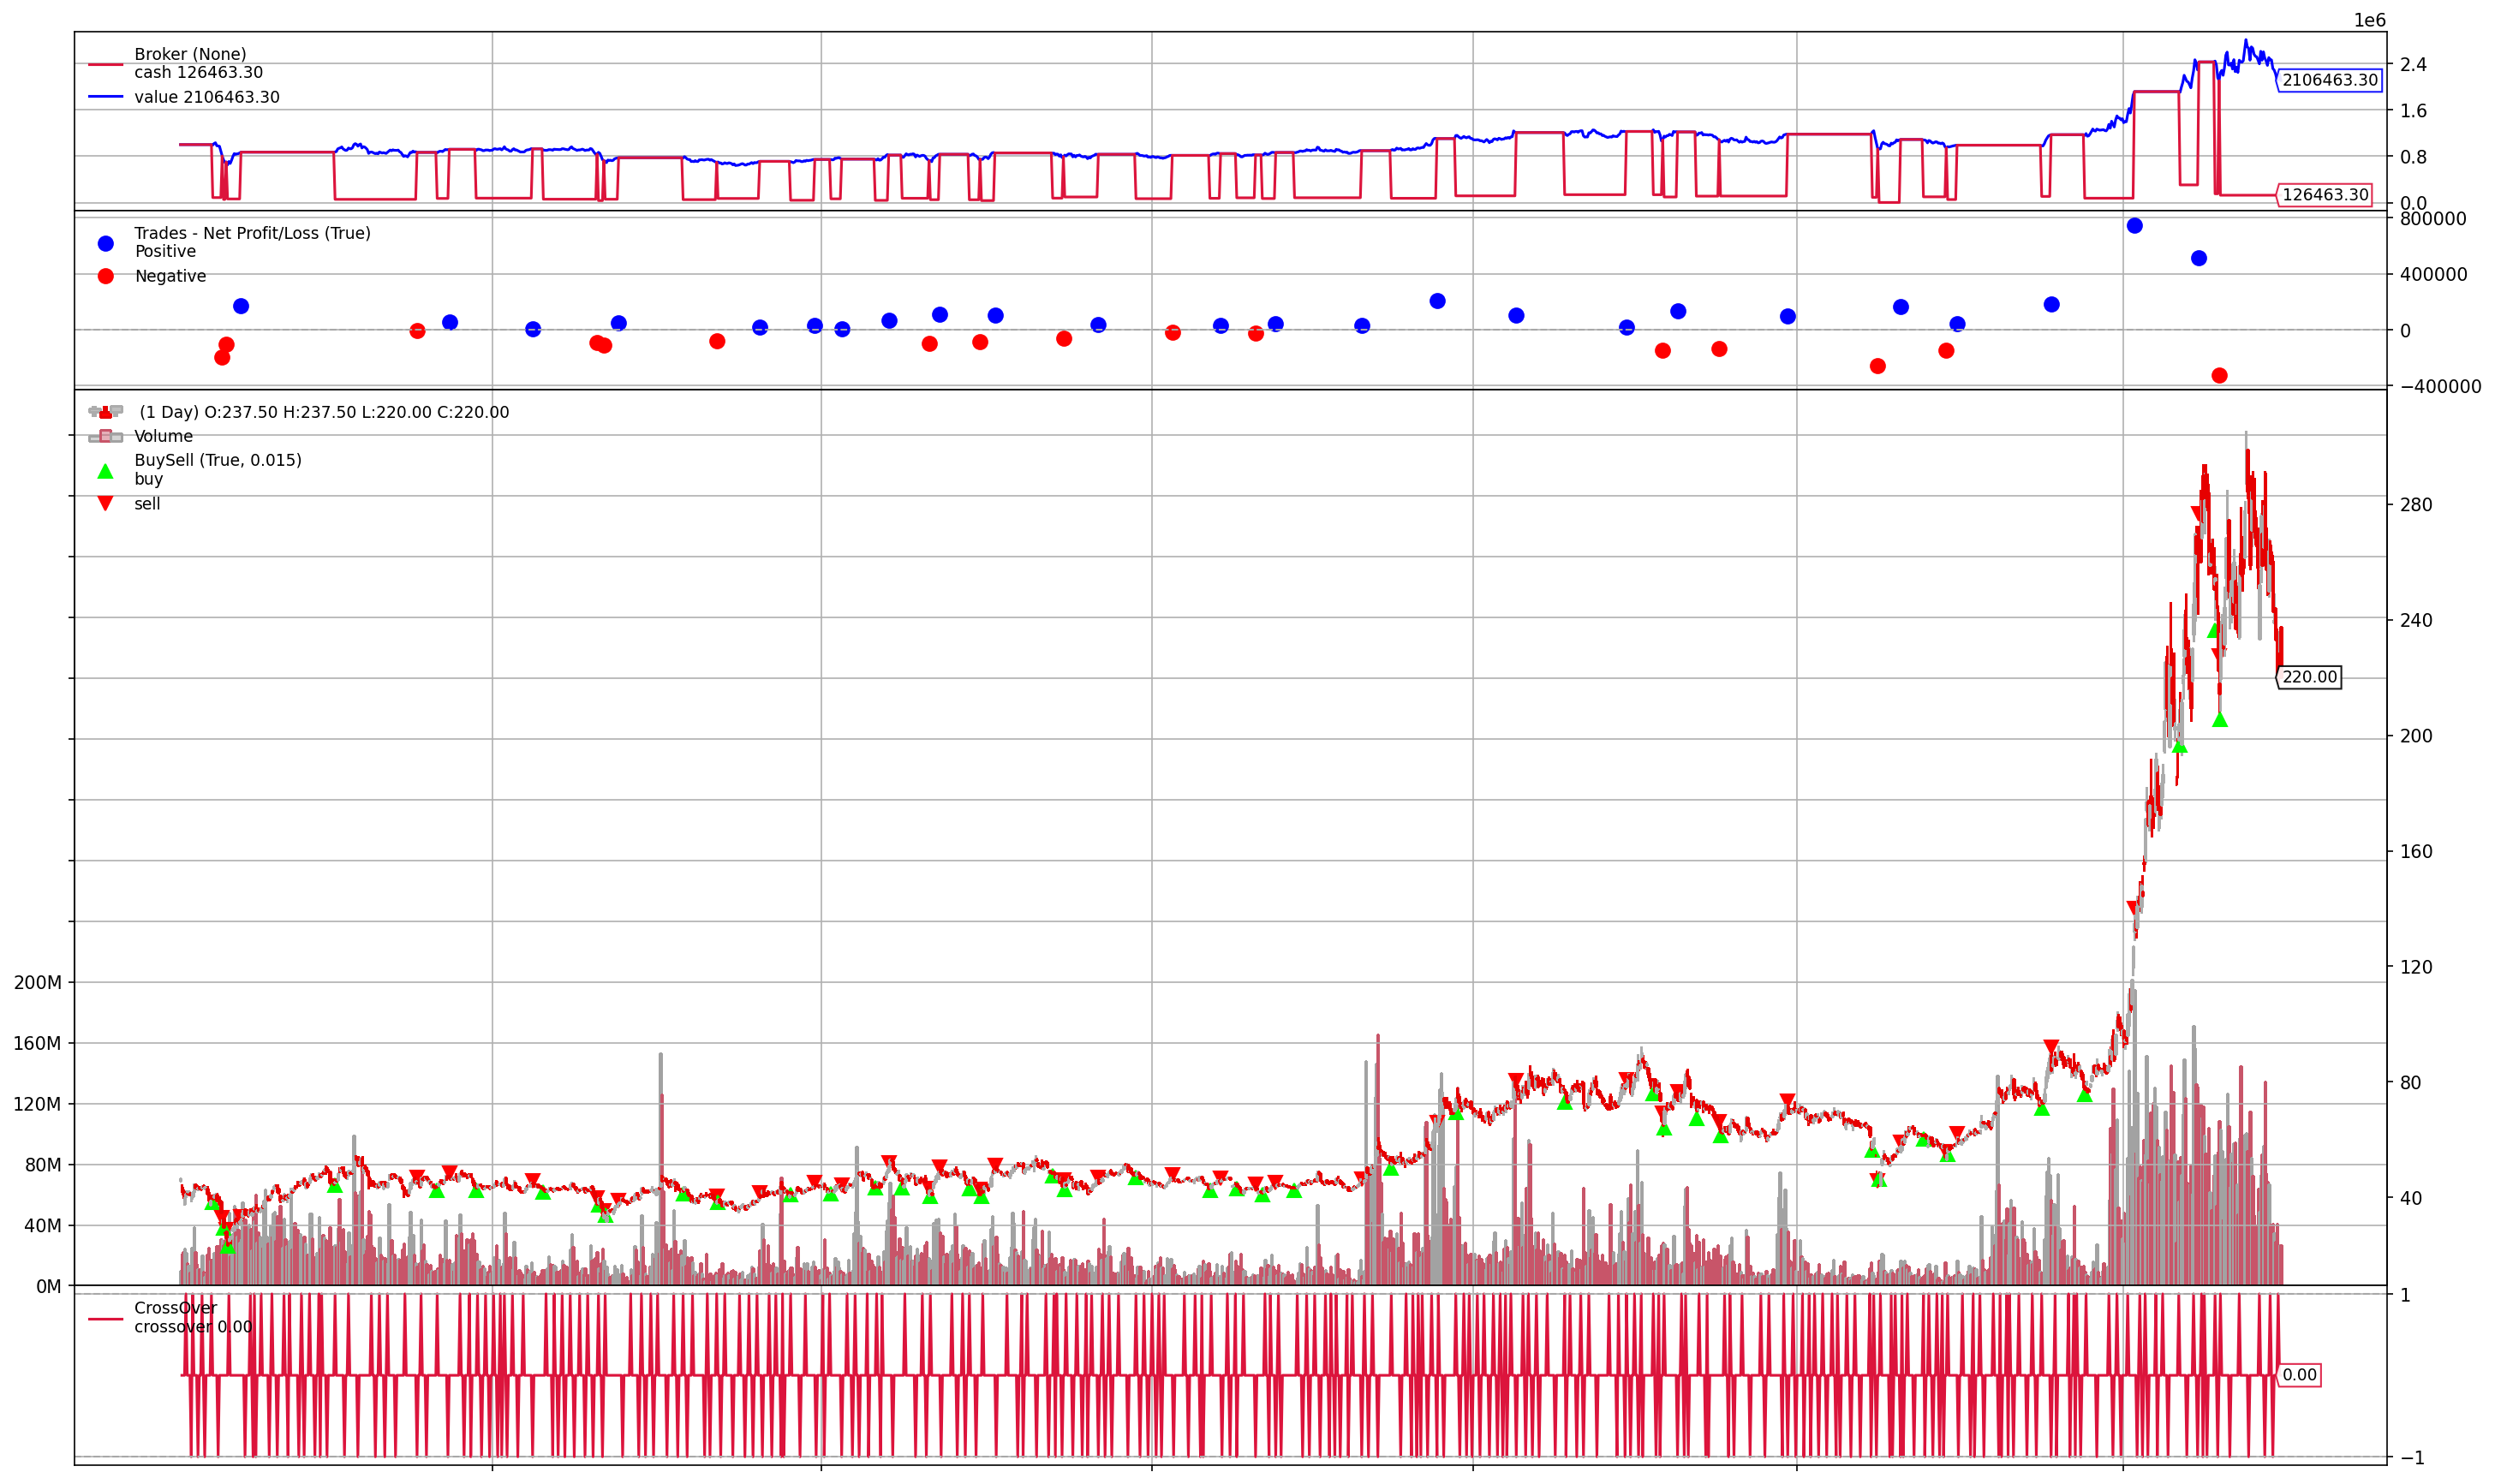


 回測標的：6257
最終資金：2,912,744.79 元
總報酬率：191.27 %
最大回撤 (MDD)：37.76 %
夏普比率(Sharpe)：0.87
總交易次數：34 次
勝率：67.65 %
賺賠比：1.51

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-05,買入,33.80,28000,946400.0,1348.62,0.00,1005651.38,0.57
1,2020-02-17,賣出,35.95,28000,1006600.0,1434.41,3019.80,1054397.18,5.44
2,2020-03-19,買入,29.50,33000,973500.0,1387.24,0.00,983709.94,-1.63
3,2020-04-08,賣出,33.35,33000,1100550.0,1568.28,3301.65,1175190.00,17.52
4,2020-06-16,買入,37.30,30000,1119000.0,1594.58,0.00,1184095.43,18.41
...,...,...,...,...,...,...,...,...,...
63,2026-03-02,賣出,143.00,14000,2002000.0,2852.85,6006.00,2059062.62,105.91
64,2026-03-11,買入,129.00,15000,1935000.0,2757.38,0.00,2093805.24,109.38
65,2026-04-02,賣出,157.00,15000,2355000.0,3355.88,7065.00,2465884.37,146.59
66,2026-06-11,買入,203.50,11000,2238500.0,3189.86,0.00,2484694.50,148.47


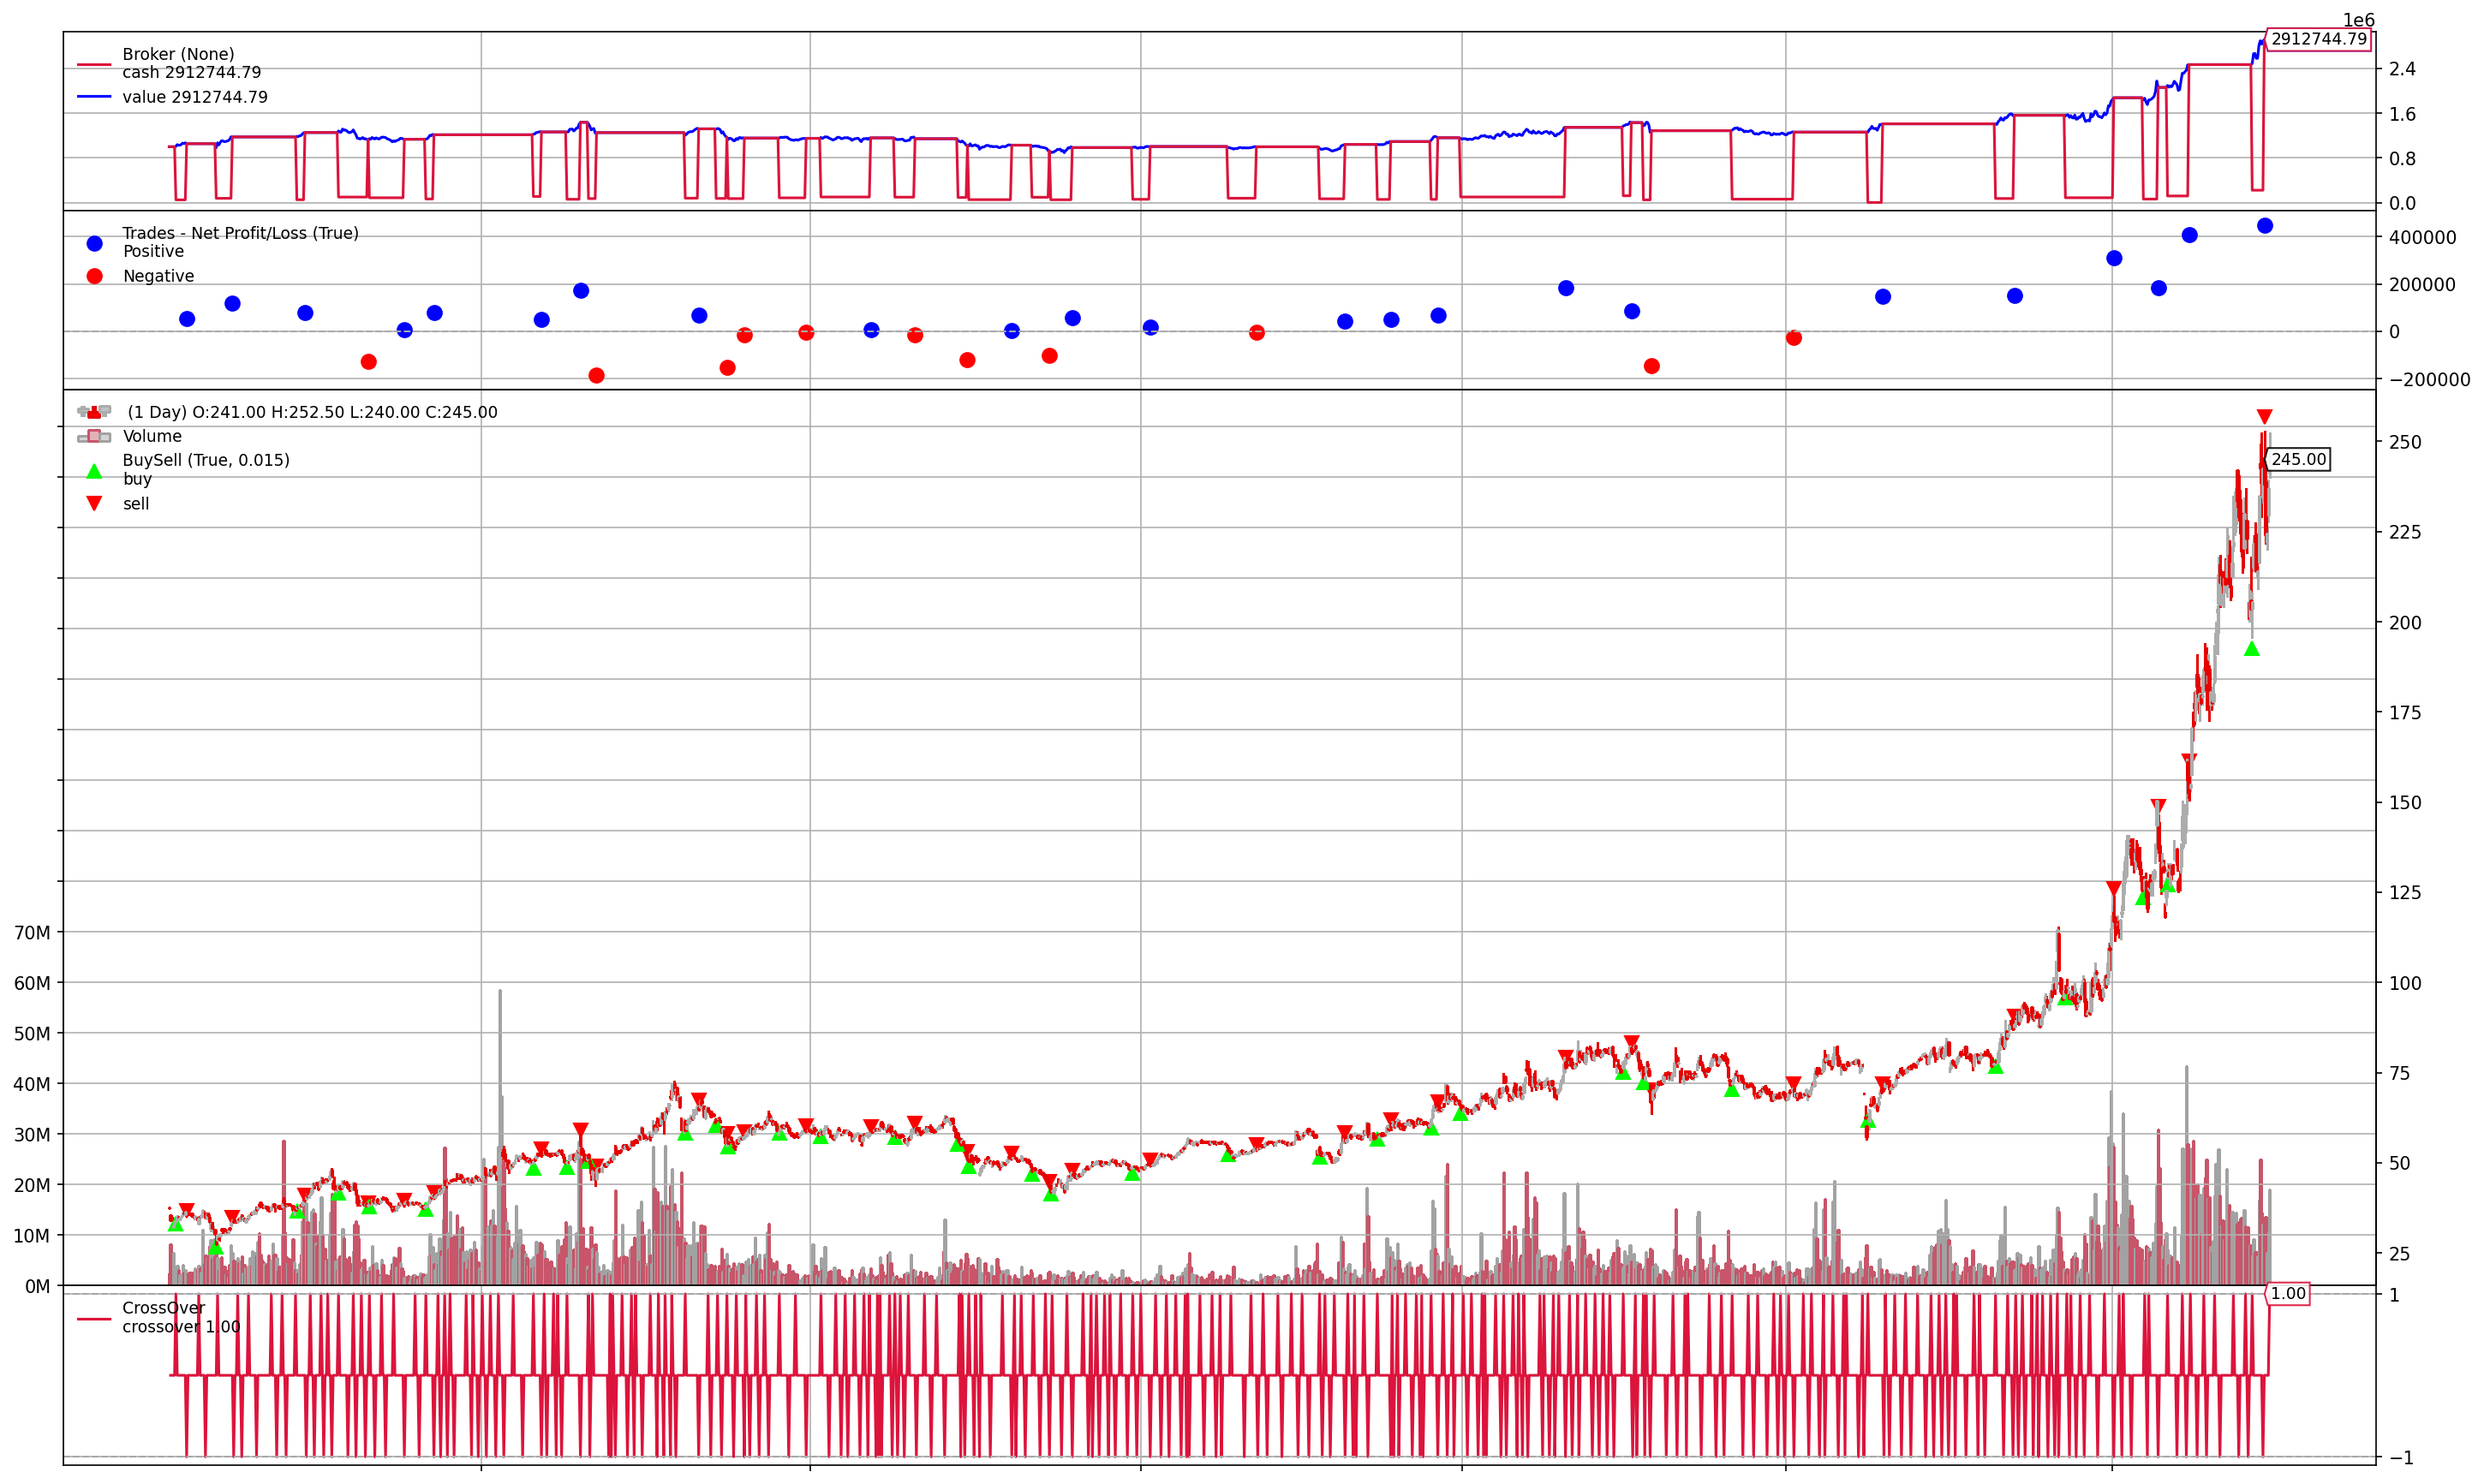


 回測標的：2382
最終資金：2,306,721.67 元
總報酬率：130.67 %
最大回撤 (MDD)：29.86 %
夏普比率(Sharpe)：0.72
總交易次數：32 次
勝率：68.75 %
賺賠比：0.88

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-03-23,買入,52.0,17000,884000.0,1259.70,0.0,1008940.30,0.89
1,2020-03-31,賣出,61.0,17000,1037000.0,1477.73,3111.0,1147151.57,14.72
2,2020-06-17,買入,68.5,16000,1096000.0,1561.80,0.0,1139189.77,13.92
3,2020-07-02,賣出,71.9,16000,1150400.0,1639.32,3451.2,1194899.25,19.49
4,2020-09-28,買入,73.7,15000,1105500.0,1575.34,0.0,1200823.92,20.08
...,...,...,...,...,...,...,...,...,...
59,2026-01-07,賣出,282.0,6000,1692000.0,2411.10,5076.0,1961588.79,96.16
60,2026-05-06,買入,328.0,5000,1640000.0,2337.00,0.0,2051751.79,105.18
61,2026-05-20,賣出,288.5,5000,1442500.0,2055.56,4327.5,1755368.73,75.54
62,2026-05-21,買入,296.0,5000,1480000.0,2109.00,0.0,1813259.73,81.33


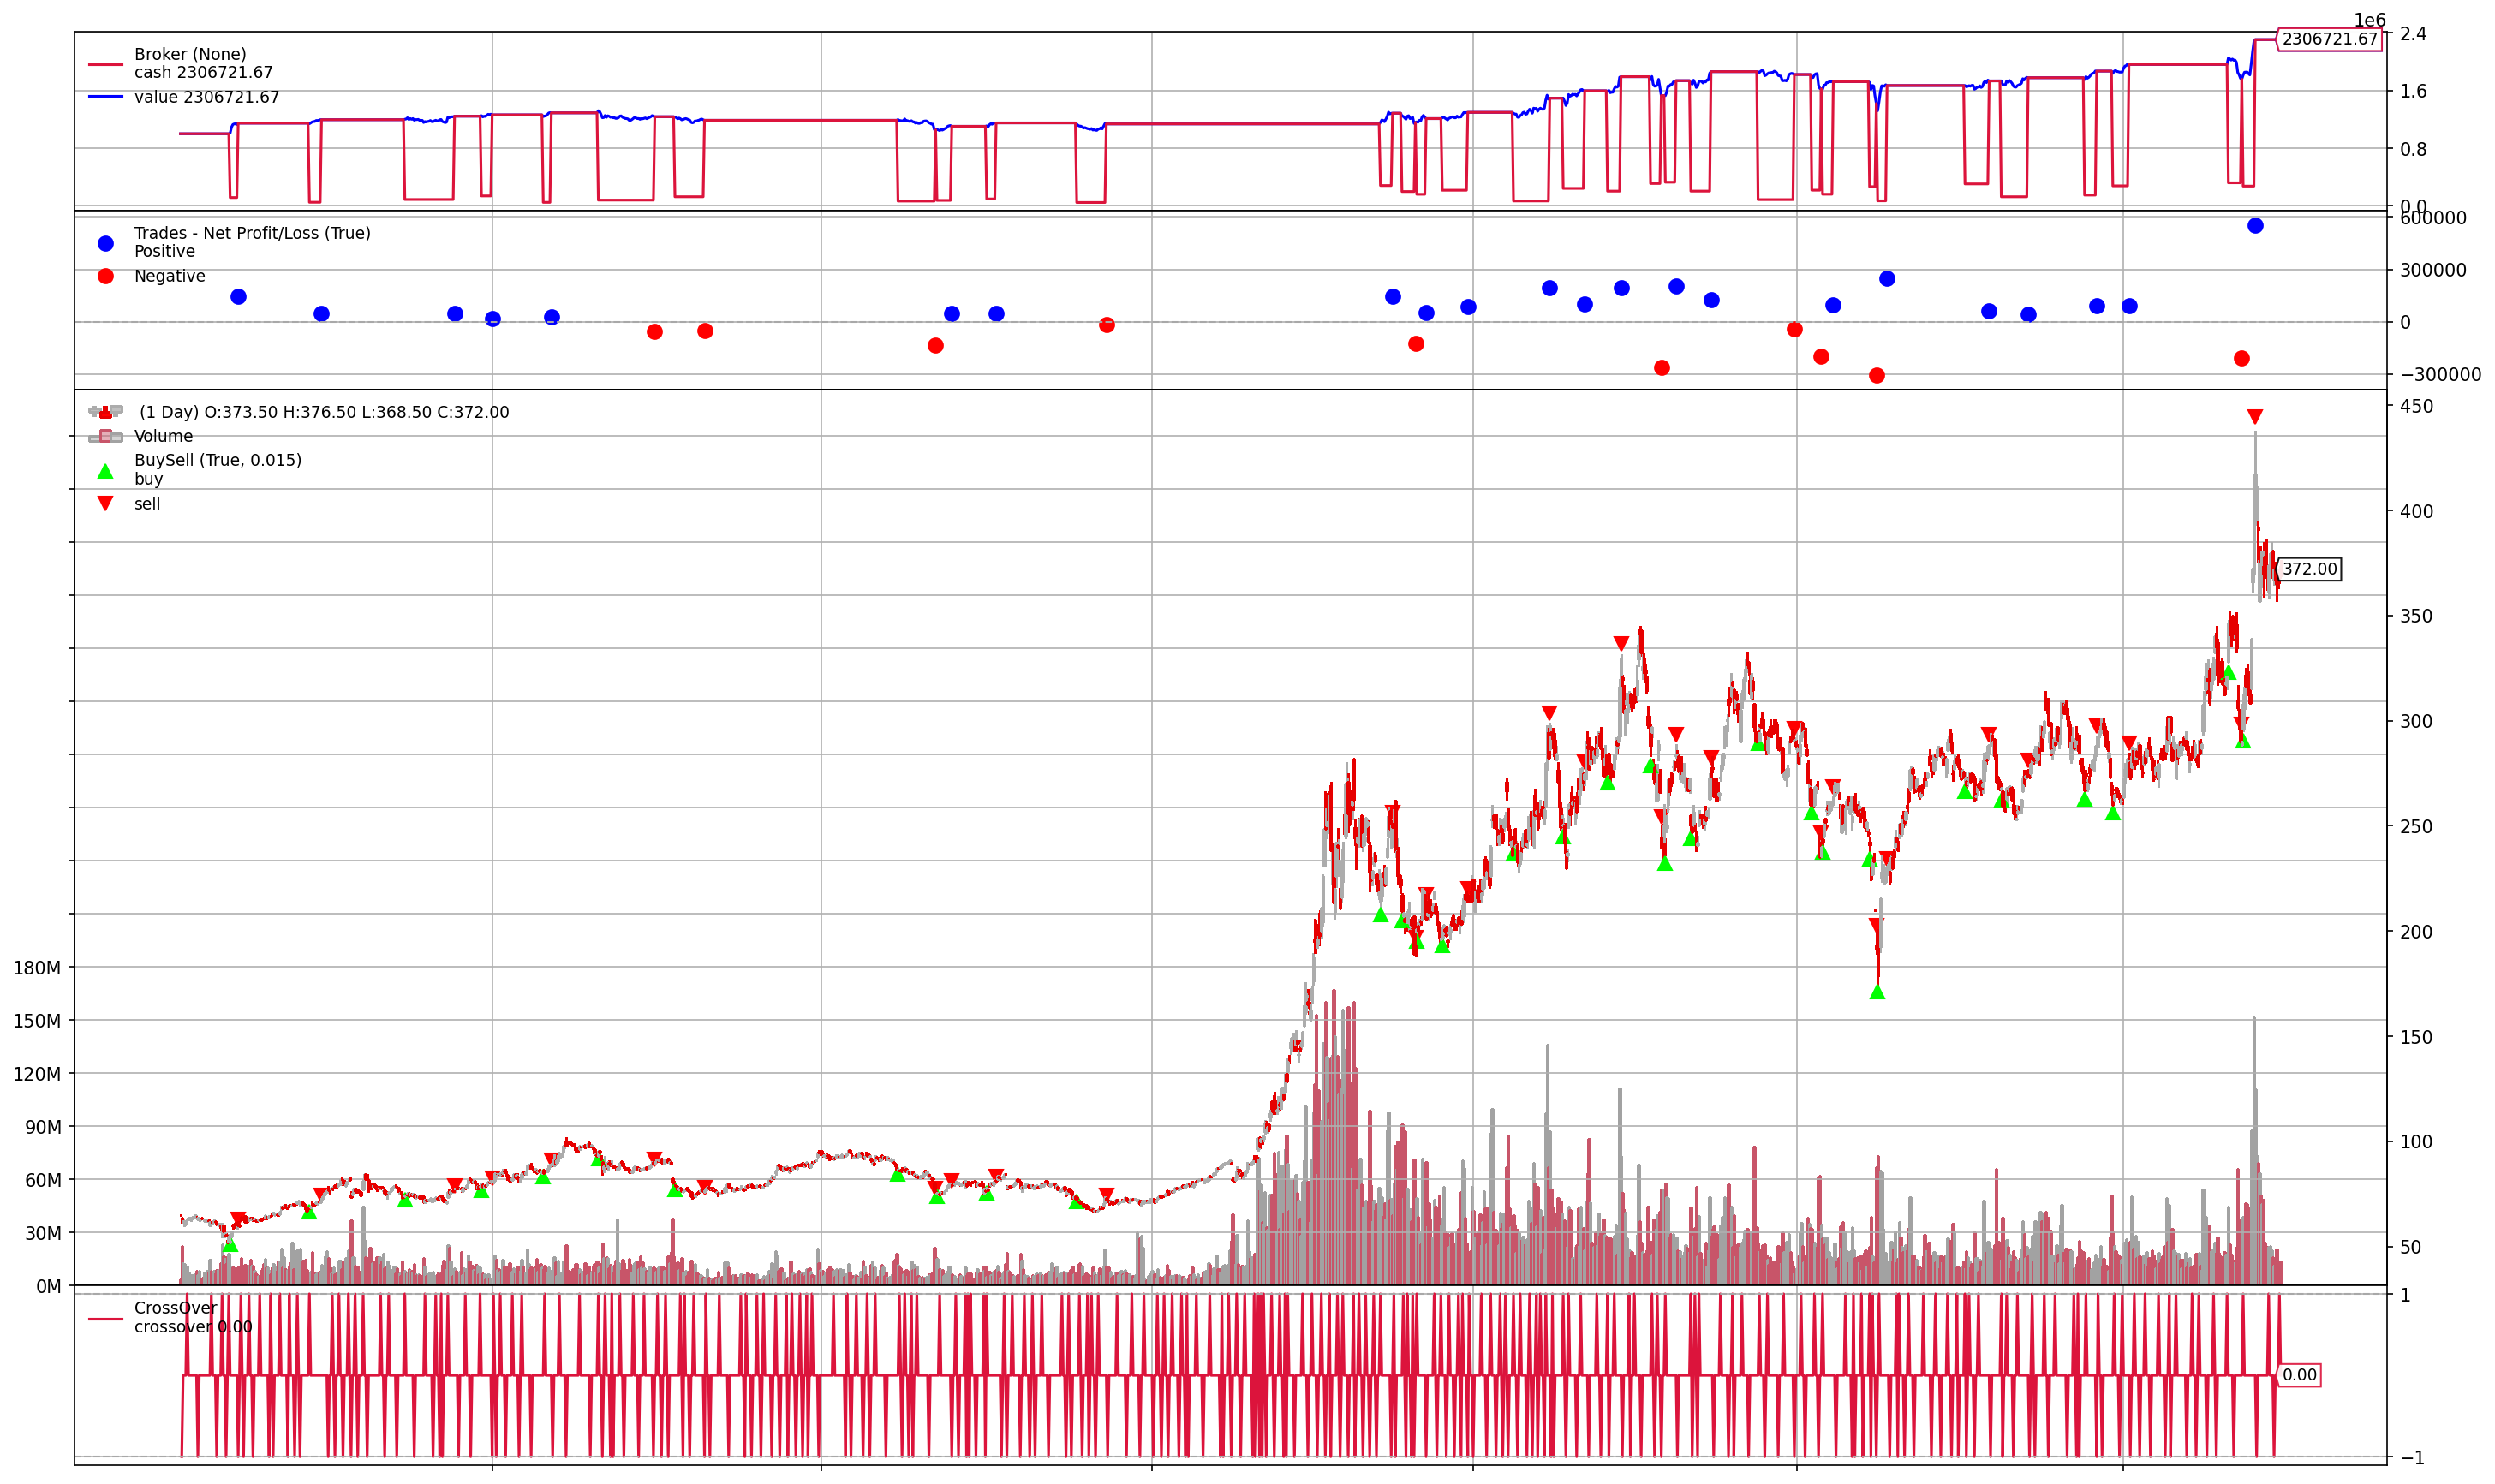


 回測標的：2317
2025-04-10 交易失敗 : Margin
最終資金：743,725.20 元
總報酬率：-25.63 %
最大回撤 (MDD)：45.92 %
夏普比率(Sharpe)：-0.27
總交易次數：30 次
勝率：53.33 %
賺賠比：0.63

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-03-13,買入,70.0,12000,840000.0,1197.00,0.0,1054003.00,5.40
1,2020-06-03,賣出,78.0,12000,936000.0,1333.80,2808.0,1090661.20,9.07
2,2020-07-28,買入,77.8,13000,1011400.0,1441.25,0.0,1097019.96,9.70
3,2020-09-17,賣出,78.6,13000,1021800.0,1456.06,3065.4,1095098.49,9.51
4,2020-09-25,買入,75.4,13000,980200.0,1396.79,0.0,1079401.70,7.94
5,2020-10-12,賣出,78.4,13000,1019200.0,1452.36,3057.6,1128191.75,12.82
6,2021-04-08,買入,123.0,8000,984000.0,1402.20,0.0,1122789.55,12.28
7,2021-05-05,賣出,110.0,8000,880000.0,1254.00,2640.0,1018895.55,1.89
8,2021-05-06,買入,112.0,8000,896000.0,1276.80,0.0,1021618.75,2.16
9,2021-05-18,賣出,101.5,8000,812000.0,1157.10,2436.0,930025.65,-7.00


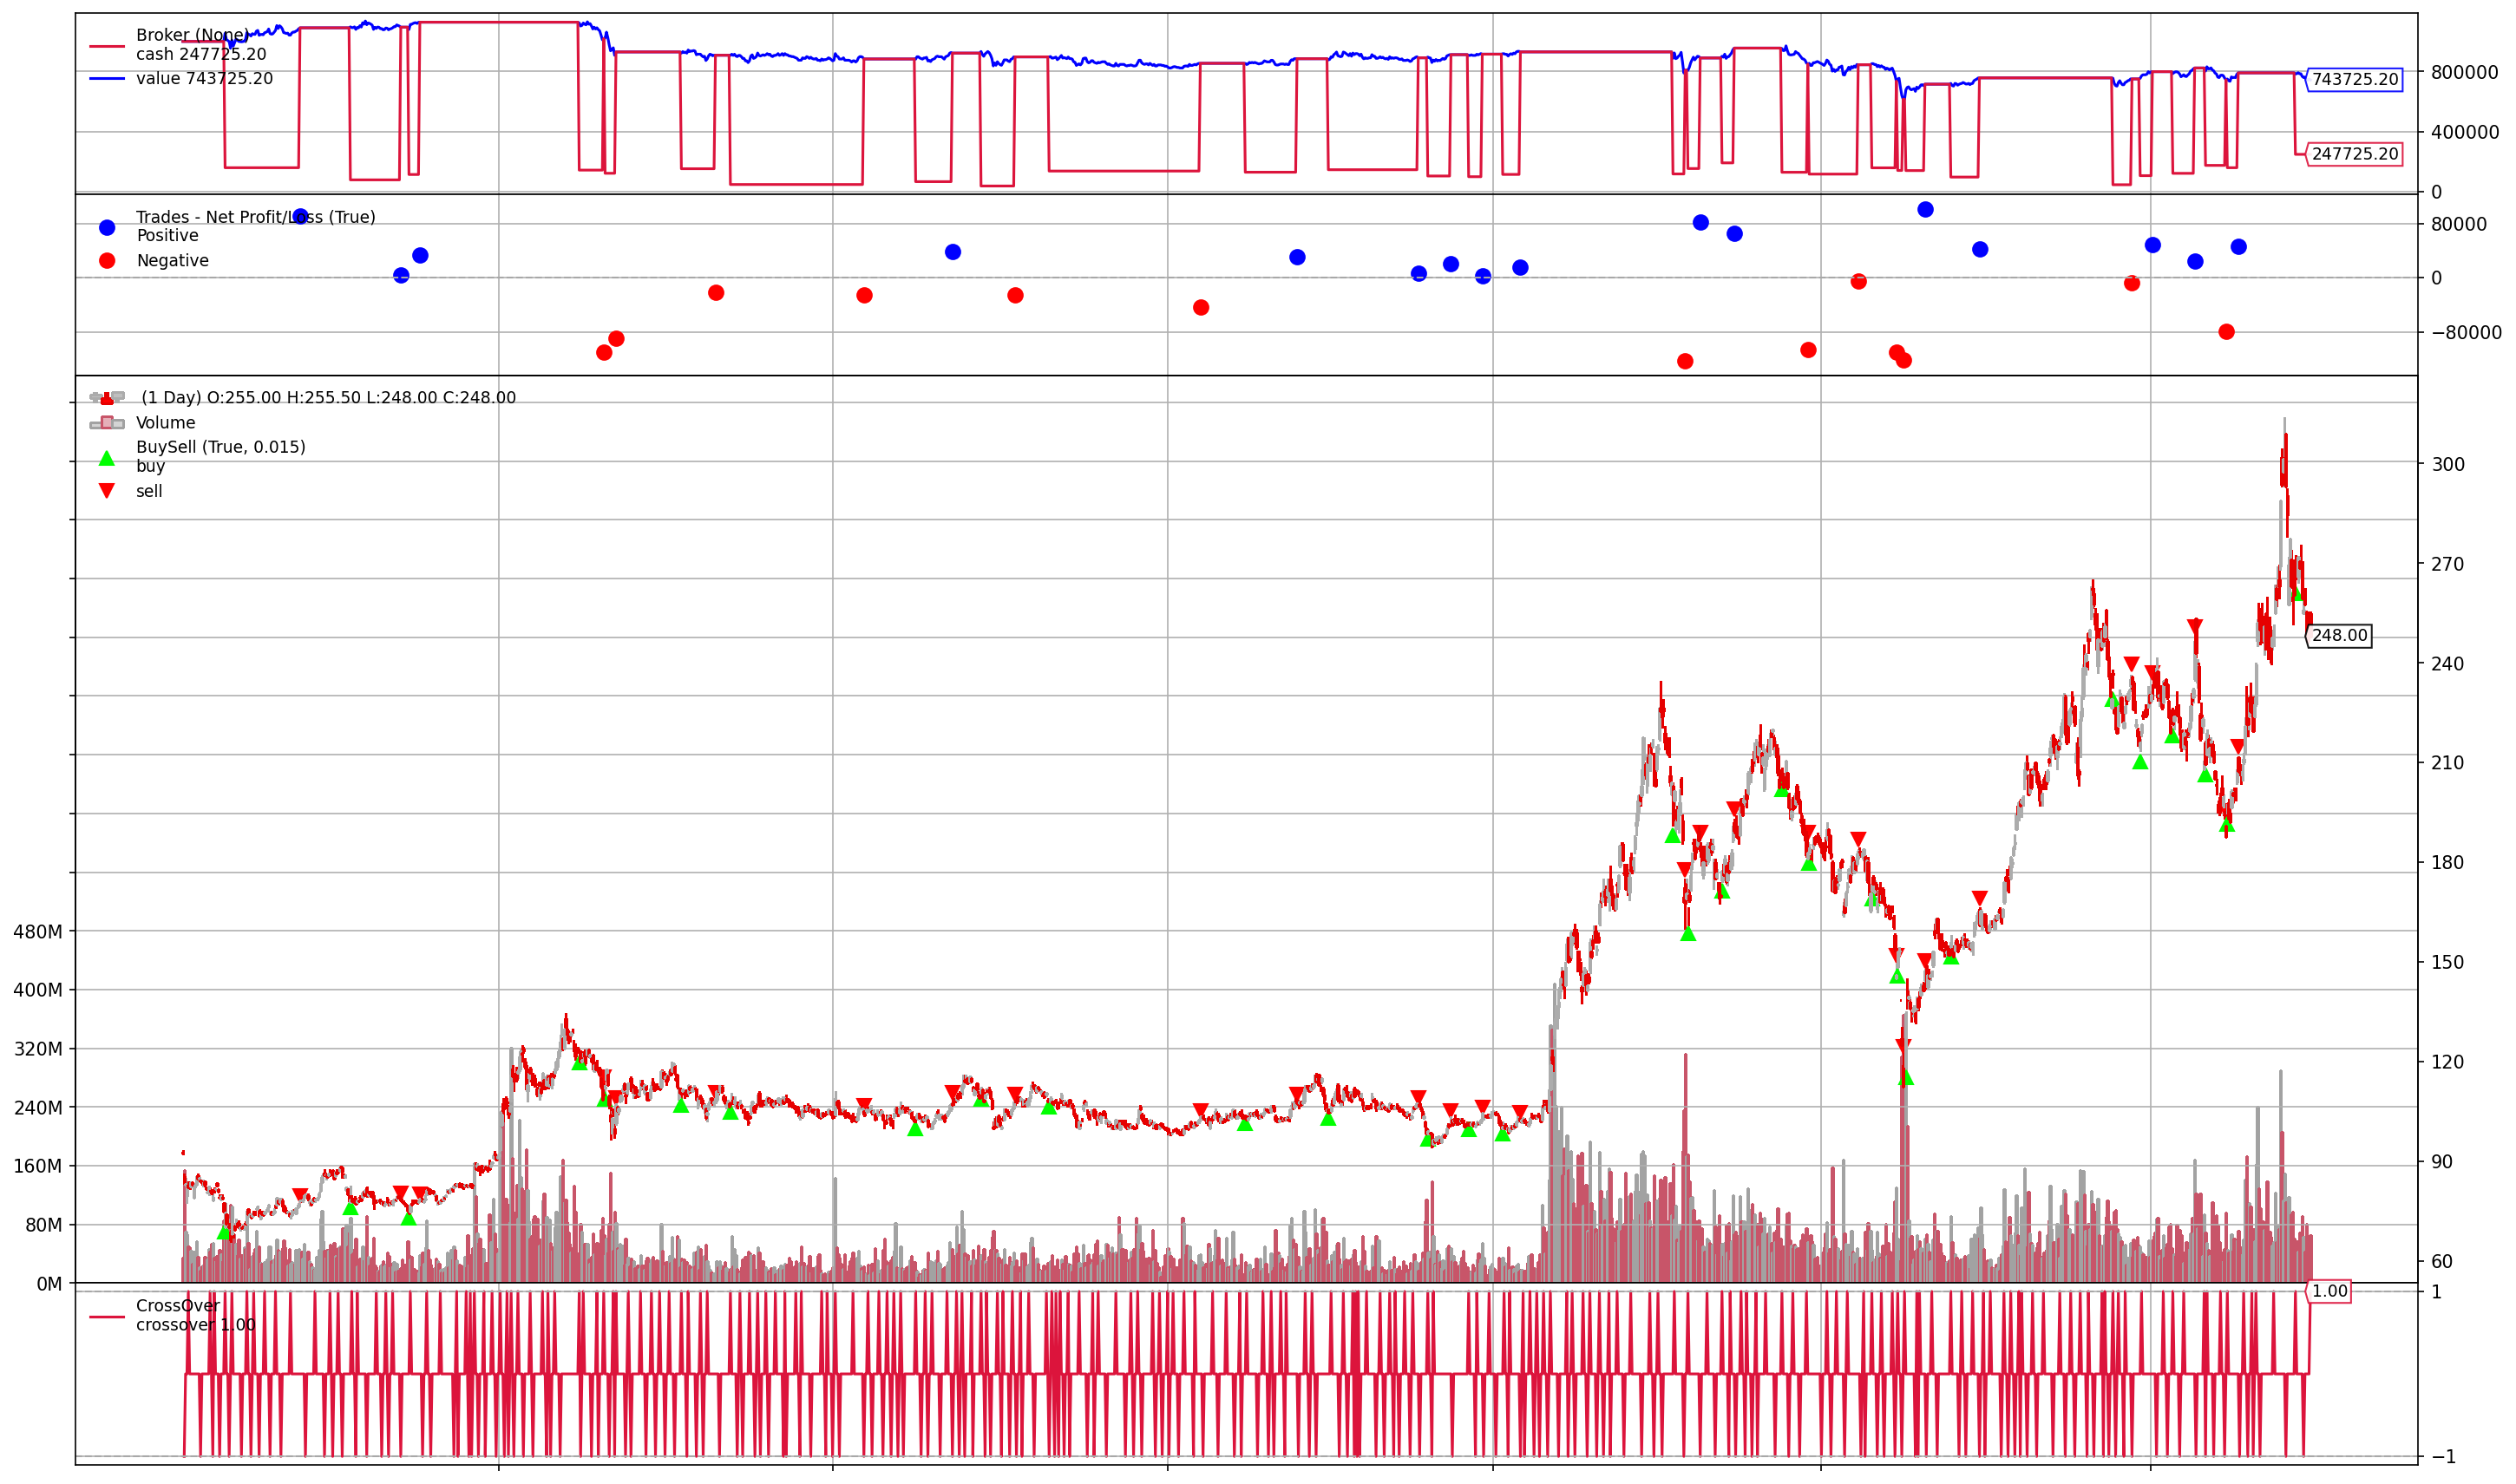


      所有股票績效總表


,標的,交易策略,最終資金 (元),總報酬率,最大回撤 (MDD),夏普比率,總交易次數,勝率,賺賠比
0,6257,KD 超買／超賣,2912744.79,191.27,37.76,0.87,34,67.65,1.51
1,2382,KD 超買／超賣,2306721.67,130.67,29.86,0.72,32,68.75,0.88
2,2313,KD 超買／超賣,2106463.30,110.65,38.06,0.48,41,60.98,1.02
3,2330,KD 超買／超賣,1082523.09,8.25,24.67,0.06,37,64.86,0.60
4,2317,KD 超買／超賣,743725.20,-25.63,45.92,-0.27,30,53.33,0.63


In [8]:
import pandas as pd
import numpy as np
import backtrader as bt
from IPython.display import display
import matplotlib.pyplot as plt

class PandasData(bt.feeds.PandasData):
    lines = ('k', 'd')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('k', 'K'),
        ('d', 'D'),
    )

class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )
    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),("lot_size", 1000),)
    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            shares = int(cash / cost_per_share)
            if shares <= 0:
              return 0

            whole_lot = (shares // self.p.lot_size) * self.p.lot_size
            if whole_lot >= self.p.lot_size:
              return whole_lot

            return shares

        return self.broker.getposition(data).size

class KDStrategy(bt.Strategy):
    params = dict(stop_loss=0.10, kd_low=20, kd_high=80)

    def __init__(self):
        self.k = self.data.k
        self.d = self.data.d
        self.cross = bt.ind.CrossOver(self.k, self.d)
        self.order = None
        self.buyprice = None
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            action = "買入" if order.isbuy() else "賣出"
            if order.isbuy():
                self.buyprice = exec_price

            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })
            # 關閉單筆印出以保持版面整潔，需要可取消註解
            # print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")

        self.order = None

    def next(self):
        if self.order:
            return
        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice
            if loss <= -self.p.stop_loss:
                # print(f"{self.data.datetime.date(0)}停損觸發")
                self.order = self.close()
                return
            if self.k[0] > self.p.kd_high and self.d[0] > self.p.kd_high:
                # print(f"{self.data.datetime.date(0)} KD高檔(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
                self.order = self.close()
                return
        else:
            if self.k[0] < self.p.kd_low and self.d[0] < self.p.kd_low:
                # print(f"{self.data.datetime.date(0)} KD低檔(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
                self.order = self.buy()

    def stop(self):
        if self.position:
            # print(f"回測結束，強制結算持股：{self.position.size}股")
            self.close()

# 執行回測
def run_backtest(ticker):
    print("\n" + "="*50)
    print(f" 回測標的：{ticker}")
    print("="*50)

    # 讀取資料
    try:
        df = pd.read_csv(f"{ticker}_Cal.csv")
    except FileNotFoundError:
        print(f"找不到檔案：{ticker}_Cal.csv，跳過此標的。")
        return

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    df_bt = df[['date', 'open', 'max', 'min', 'close', 'K', 'D', 'Trading_Volume']].copy()
    df_bt = df_bt.rename(columns={"max": "high", "min": "low", "Trading_Volume": "volume"})
    df_bt = df_bt.dropna().reset_index(drop=True)
    df_bt = df_bt.set_index("date")

    # Cerebro
    cerebro = bt.Cerebro()
    cerebro.addstrategy(KDStrategy)
    cerebro.addsizer(AllInSizer, reserve=0.05)

    data = PandasData(dataname=df_bt)
    cerebro.adddata(data)
    cerebro.broker.setcash(1_000_000)

    comminfo = TaiwanStockCommission()
    cerebro.broker.addcommissioninfo(comminfo)

    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    # 執行回測
    results = cerebro.run()
    strat = results[0]

    # 整理表格
    df_trades = pd.DataFrame(strat.trades_history)
    final_val = cerebro.broker.getvalue()
    pnl_pct = (final_val / 1_000_000 - 1) * 100

    if strat.position:
        last_date = strat.data.datetime.date(0)
        pos_size = strat.position.size
        close_price = strat.data.close[0]
        unrealized_value = pos_size * close_price

        unrealized_row = pd.DataFrame([{
            "交易日期": last_date, "買賣別": "結算",
            "成交價": round(close_price, 2), "成交量(股)": pos_size,
            "交易金額": round(unrealized_value, 2), "手續費": 0.0, "證交稅": 0.0,
            "總資產": round(final_val, 2), "目前報酬率(%)": round(pnl_pct, 2)
        }])
        df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

    # 輸出 CSV
    df_trades.to_csv(f'{ticker}_df_trades.csv', index=False)

    # 績效指標計算
    mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
    sharpe_info = strat.analyzers.sharpe.get_analysis()
    sharpe = sharpe_info.get('sharperatio', None)

    trade_pnls = []
    raw_trades = df_trades[df_trades['買賣別'] != '結算'].copy()
    buy_record = None
    for _, row in df_trades.iterrows():
        if row['買賣別'] == '買入':
            buy_record = row
        elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
            cost = buy_record['交易金額'] + buy_record['手續費']
            revenue = row['交易金額'] - row['手續費'] - row['證交稅']
            pnl = revenue - cost
            trade_pnls.append(pnl)
            buy_record = None

    trade_pnls = np.array(trade_pnls)
    if len(trade_pnls) > 0:
        wins = trade_pnls[trade_pnls > 0]
        losses = trade_pnls[trade_pnls < 0]
        win_rate = (len(wins) / len(trade_pnls)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
        profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
    else:
        win_rate = profit_factor = 0.0

    print(f"最終資金：{final_val:,.2f} 元")
    print(f"總報酬率：{pnl_pct:.2f} %")
    print(f"最大回撤 (MDD)：{mdd:.2f} %")
    print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率(Sharpe)：無法計算 (無交易)")
    print(f"總交易次數：{len(trade_pnls)} 次")
    print(f"勝率：{win_rate:.2f} %")
    print(f"賺賠比：{profit_factor:.2f}")

    print("\n=== 交易紀錄表 ===")
    display(df_trades)

    # 繪圖
    plt.rcParams['figure.figsize'] = [20, 12]
    plt.rcParams['figure.dpi'] = 150
    cerebro.plot(style="candlestick", iplot=False, heightp=0.5)
    plt.show()

    return {
        "標的": ticker,
        "交易策略": "KD 超買／超賣", #　交易策略有變動的話需更改
        "最終資金 (元)": round(final_val, 2),
        "總報酬率": round(pnl_pct, 2),
        "最大回撤 (MDD)": round(mdd, 2),
        "夏普比率": round(sharpe, 2) if sharpe is not None else np.nan,
        "總交易次數": len(trade_pnls),
        "勝率": round(win_rate, 2),
        "賺賠比": round(profit_factor, 2) if not np.isnan(profit_factor) else np.nan}

performance_summary = []
# 標的清單
stock_list = ["2330", "2313", "6257", "2382", "2317"]

for stock_id in stock_list:
    # run_backtest(stock_id)
    result = run_backtest(stock_id)

    if result is not None:
      performance_summary.append(result)
df_summary = pd.DataFrame(performance_summary)

# 依照報酬率排序
df_summary = df_summary.sort_values(by="總報酬率", ascending=False).reset_index(drop=True)

print("\n==============================")
print("      所有股票績效總表")
print("==============================")

display(df_summary)

df_summary.to_csv("KD_OBOS_Backtest_Performance.csv", index=False, encoding="utf-8-sig")

# 參考資料

https://ithelp.ithome.com.tw/m/articles/10242427

https://vocus.cc/article/67f8ebfbfd8978000177661f

https://finlab.finance/blog/what-is-backtesting